In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Download MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset Shape:", X.shape)
print("Labels Shape :", y.shape)

Dataset Shape: (70000, 784)
Labels Shape : (70000,)


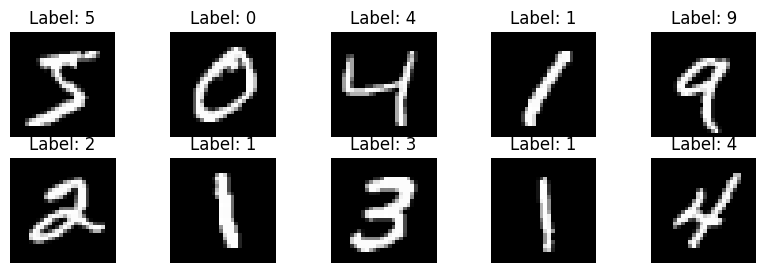

In [4]:
plt.figure(figsize=(10,3))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X[i].reshape(28,28), cmap="gray")
    plt.title("Label: "+str(y[i]))
    plt.axis("off")

plt.show()

In [5]:
X = X / 255.0

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 56000
Testing Samples  : 14000


In [7]:
model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    multi_class="auto"
)

model.fit(X_train, y_train)

print("Training Completed")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Completed


In [8]:
train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy =", train_accuracy)

Training Accuracy = 0.9389642857142857


In [10]:
test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)

print("Test Accuracy =", test_accuracy)

Test Accuracy = 0.9202142857142858


In [11]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.91      0.89      0.90      1380
           3       0.90      0.89      0.90      1433
           4       0.92      0.93      0.93      1295
           5       0.88      0.88      0.88      1273
           6       0.94      0.95      0.95      1396
           7       0.93      0.94      0.93      1503
           8       0.90      0.87      0.88      1357
           9       0.90      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



In [12]:
cm = confusion_matrix(y_test, test_pred)

print(cm)

[[1297    1    7    0    3   11   12    4    6    2]
 [   0 1548    6   10    3   12    0    4   15    2]
 [   5   20 1233   20   15   10   21   17   29   10]
 [   6   10   30 1281    1   39    7   18   23   18]
 [   5    3    6    5 1202    5   10    8    7   44]
 [   4   12    8   43   11 1119   22    4   36   14]
 [   5    5   19    1   14   17 1331    1    3    0]
 [   6    4   26    3   10    6    0 1416    1   31]
 [  10   27   14   44    6   42    9    9 1177   19]
 [   8   11    5   13   36    7    0   46   15 1279]]


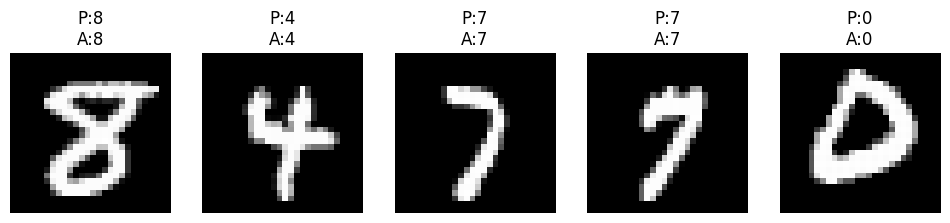

In [13]:
correct = np.where(test_pred == y_test)[0]

plt.figure(figsize=(12,3))

for i in range(5):

    index = correct[i]

    plt.subplot(1,5,i+1)
    plt.imshow(X_test[index].reshape(28,28), cmap="gray")

    plt.title("P:{}\nA:{}".format(
        test_pred[index],
        y_test[index]
    ))

    plt.axis("off")

plt.show()

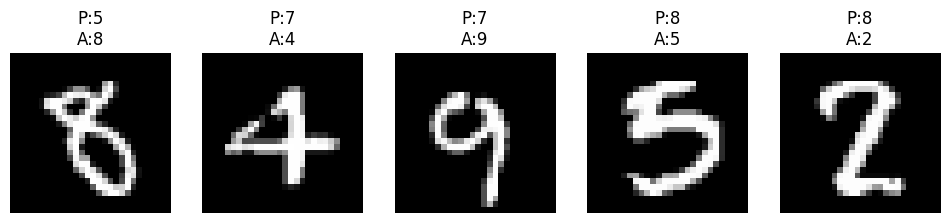

In [14]:
incorrect = np.where(test_pred != y_test)[0]

plt.figure(figsize=(12,3))

for i in range(5):

    index = incorrect[i]

    plt.subplot(1,5,i+1)
    plt.imshow(X_test[index].reshape(28,28), cmap="gray")

    plt.title("P:{}\nA:{}".format(
        test_pred[index],
        y_test[index]
    ))

    plt.axis("off")

plt.show()

In [15]:
print("========== RESULTS ==========")

print("Training Accuracy :", train_accuracy)

print("Testing Accuracy  :", test_accuracy)

print("\nClassification Report\n")

print(classification_report(y_test, test_pred))

========== RESULTS ==========
Training Accuracy : 0.9389642857142857
Testing Accuracy  : 0.9202142857142858

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.91      0.89      0.90      1380
           3       0.90      0.89      0.90      1433
           4       0.92      0.93      0.93      1295
           5       0.88      0.88      0.88      1273
           6       0.94      0.95      0.95      1396
           7       0.93      0.94      0.93      1503
           8       0.90      0.87      0.88      1357
           9       0.90      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000

